# RetinaVLM: 논문 결과 재현 (Inference Only)

이 노트북은 **학습(Fine-tuning) 없이** 이미 학습된 `RetinaVLM-Specialist` 가중치를 사용하여 OCT 이미지를 분석합니다.

### 모델 구성
- **Vision Encoder**: ResNet50 (Pre-trained on Specialist task)
- **Projection Layer**: Pre-trained & Aligned Linear Layer
- **LLM**: Llama3-8B-Instruct

이 코드는 `dataset/processed_images` 경로의 실제 데이터를 사용하여 논문의 성능을 확인합니다.

In [1]:
import os, sys, torch, glob
from PIL import Image
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra import initialize, compose

# GPU 3 지정
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# 프로젝트 경로 설정 (현재 폴더를 루트로 설정)
PROJECT_DIR = os.path.abspath(".")
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from models.retinavlm_wrapper import load_retinavlm_specialist_from_hf

# 장치 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/ubuntu/bionexus/jgy/miniconda3/envs/oct_llm/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(

Using device: cuda
GPU Name: NVIDIA H100 80GB HBM3


In [2]:
# =====================================================
#  학습된 RetinaVLM-Specialist 모델 로드
# =====================================================

# 경로 중복 방지를 위해 PROJECT_DIR 사용
with initialize(version_base=None, config_path="configs"):
    config = compose(config_name="default")

# pretrained_model_dir을 로컬 캐시 경로로 오버라이드 (Windows 경로 문제 해결)
OmegaConf.update(config, "pretrained_model_dir", os.path.expanduser("~/.cache/huggingface/hub"), force_add=True)

print(f"pretrained_model_dir: {config.pretrained_model_dir}")
print("Loading pre-trained RetinaVLM-Specialist from HuggingFace...")
model = load_retinavlm_specialist_from_hf(config)
model.to(DEVICE)
model.eval()
print("Model loaded successfully!")

pretrained_model_dir: /home/ubuntu/bionexus/jgy/.cache/huggingface/hub
Loading pre-trained RetinaVLM-Specialist from HuggingFace...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights from HuggingFace...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


`torch_dtype` is deprecated! Use `dtype` instead!


Detected meta device context — creating empty Llama3 model (weights will be loaded by outer from_pretrained)
Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)


Loading weights: 100%|██████████| 611/611 [00:16<00:00, 37.39it/s]
RetinaVLM LOAD REPORT from: RobbieHolland/RetinaVLM
Key                                                                                               | Status     | 
--------------------------------------------------------------------------------------------------+------------+-
model.llm.model.model.layers.{0...31}.self_attn.q_proj.weight_format                              | UNEXPECTED | 
model.llm.model.model.layers.{0...31}.mlp.down_proj.weight_format                                 | UNEXPECTED | 
model.llm.model.model.layers.{0...31}.mlp.gate_proj.weight_format                                 | UNEXPECTED | 
model.llama_model.model.layers.{0...31}.mlp.down_proj.weight_format                               | UNEXPECTED | 
model.llm.model.model.layers.{0...31}.mlp.up_proj.SCB                                             | UNEXPECTED | 
model.llm.model.model.layers.{0...31}.self_attn.v_proj.SCB                         

Model loaded successfully!


In [3]:
# =====================================================
#  가중치 로딩 진단 (Weight Loading Diagnostics)
# =====================================================
# 목적: 어떤 컴포넌트의 가중치가 제대로 로드되었는지 확인
# - ResNet50 (visual_encoder)
# - Projection Layer (llama_proj)
# - Llama3 (llm / llama_model)

import torch
import numpy as np
from huggingface_hub import hf_hub_download
from safetensors import safe_open

print("=" * 70)
print(" 1. HuggingFace 체크포인트에 저장된 키 분석")
print("=" * 70)

# HF 체크포인트의 실제 키 확인
repo_id = "RobbieHolland/RetinaVLM"
subfolder = "RetinaVLM-Specialist"

# safetensors index 다운로드하여 키 목록 확인
try:
    index_path = hf_hub_download(repo_id, f"{subfolder}/model.safetensors.index.json", cache_dir=config.pretrained_model_dir)
    import json
    with open(index_path) as f:
        index = json.load(f)
    
    checkpoint_keys = list(index["weight_map"].keys())
    print(f"체크포인트 총 키 수: {len(checkpoint_keys)}")
    
    # 컴포넌트별 분류
    categories = {
        "visual_encoder": [],
        "llama_proj": [],
        "llm.model": [],
        "llama_model": [],
        "learnable_p_tokens": [],
        "learnable_s_tokens": [],
        "기타": [],
    }
    
    for key in checkpoint_keys:
        categorized = False
        for cat in categories:
            if cat in key:
                categories[cat].append(key)
                categorized = True
                break
        if not categorized:
            categories["기타"].append(key)
    
    print("\n[체크포인트 키 분류]")
    for cat, keys in categories.items():
        if keys:
            # SCB/weight_format 키 분리
            normal_keys = [k for k in keys if not any(x in k for x in ['SCB', 'weight_format'])]
            quant_keys = [k for k in keys if any(x in k for x in ['SCB', 'weight_format'])]
            print(f"  {cat}: {len(normal_keys)} normal + {len(quant_keys)} quantization metadata = {len(keys)} total")
            # 샘플 키 출력
            for k in normal_keys[:3]:
                print(f"    예: {k}")
            if quant_keys:
                print(f"    (8-bit 관련: SCB={sum('SCB' in k for k in quant_keys)}, weight_format={sum('weight_format' in k for k in quant_keys)})")
    
except Exception as e:
    print(f"Index 파일 로드 실패: {e}")
    checkpoint_keys = []

print("\n" + "=" * 70)
print(" 2. 현재 모델의 가중치 통계 분석")
print("=" * 70)
print(" (랜덤 초기화 vs 학습된 가중치 구분)")
print(" → mean≈0, std≈작은값: 정상 학습된 가중치")
print(" → mean≈0, std≈큰값(0.01~0.1): 랜덤 초기화 의심")
print(" → 모든 값 0 또는 1: 초기화 안 됨\n")

inner_model = model.model  # MiniGPT4 instance

def weight_stats(name, param):
    """가중치 텐서의 통계를 요약"""
    p = param.float()
    return {
        "shape": tuple(param.shape),
        "dtype": str(param.dtype),
        "device": str(param.device),
        "mean": p.mean().item(),
        "std": p.std().item(),
        "min": p.min().item(),
        "max": p.max().item(),
        "all_zero": (p == 0).all().item(),
        "num_params": param.numel(),
    }

# 2a. Visual Encoder (ResNet50)
print("[2a] Visual Encoder (ResNet50)")
print("-" * 50)
ve_params = {n: p for n, p in inner_model.visual_encoder.named_parameters()}
ve_buffers = {n: b for n, b in inner_model.visual_encoder.named_buffers()}
total_ve = sum(p.numel() for p in ve_params.values()) + sum(b.numel() for b in ve_buffers.values())
zero_params = sum(1 for p in ve_params.values() if (p.float() == 0).all().item())
print(f"  파라미터 수: {len(ve_params)}, 버퍼 수: {len(ve_buffers)}, 총 원소: {total_ve:,}")
print(f"  모두 0인 파라미터: {zero_params}/{len(ve_params)}")

# 대표 레이어 확인
for name in ["feature_tokens_model.0.weight", "feature_tokens_model.4.0.conv1.weight", "feature_tokens_model.7.2.conv3.weight"]:
    if name in ve_params:
        s = weight_stats(name, ve_params[name])
        status = "ALL ZERO ❌" if s["all_zero"] else f"mean={s['mean']:.6f}, std={s['std']:.6f} ✓"
        print(f"  {name}: {status}")

# 2b. Projection Layer
print(f"\n[2b] Projection Layer (llama_proj)")
print("-" * 50)
proj_params = {n: p for n, p in inner_model.llama_proj.named_parameters()}
total_proj = sum(p.numel() for p in proj_params.values())
print(f"  파라미터 수: {len(proj_params)}, 총 원소: {total_proj:,}")
for name, param in proj_params.items():
    s = weight_stats(name, param)
    status = "ALL ZERO ❌" if s["all_zero"] else f"mean={s['mean']:.6f}, std={s['std']:.6f} ✓"
    print(f"  {name}: {s['shape']} {s['dtype']} → {status}")

# 2c. Language Model (Llama3)
print(f"\n[2c] Language Model (Llama3 via llm)")
print("-" * 50)
llm_params = list(inner_model.llm.model.named_parameters())
total_llm = sum(p.numel() for _, p in llm_params)
zero_llm = sum(1 for _, p in llm_params if (p.float() == 0).all().item())
print(f"  파라미터 수: {len(llm_params)}, 총 원소: {total_llm:,}")
print(f"  모두 0인 파라미터: {zero_llm}/{len(llm_params)}")

# 대표 레이어 확인
sample_layers = ["model.embed_tokens.weight", "model.layers.0.self_attn.q_proj.weight", 
                 "model.layers.15.mlp.gate_proj.weight", "model.layers.31.self_attn.v_proj.weight",
                 "lm_head.weight"]
for name in sample_layers:
    found = False
    for pname, param in llm_params:
        if pname == name:
            s = weight_stats(name, param)
            status = "ALL ZERO ❌" if s["all_zero"] else f"mean={s['mean']:.6f}, std={s['std']:.6f}"
            # 랜덤 초기화 감지 (kaiming init의 경우 std가 보통 0.01~0.1)
            if not s["all_zero"] and s["std"] > 0.05:
                status += " (⚠️ 랜덤 초기화 가능성)"
            else:
                status += " ✓"
            print(f"  {name}: {s['dtype']} → {status}")
            found = True
            break
    if not found:
        print(f"  {name}: NOT FOUND ❌")

# 2d. llm.model vs llama_model 동일성 확인
print(f"\n[2d] llm.model vs llama_model 참조 동일성")
print("-" * 50)
is_same_obj = inner_model.llm.model is inner_model.llama_model
print(f"  같은 객체인가? {is_same_obj}")
if not is_same_obj:
    print("  ⚠️ 서로 다른 객체! 체크포인트 키 충돌 가능성 있음")
    # 가중치 비교
    llm_p = dict(inner_model.llm.model.named_parameters())
    llama_p = dict(inner_model.llama_model.named_parameters())
    common_keys = set(llm_p.keys()) & set(llama_p.keys())
    if common_keys:
        sample_key = list(common_keys)[0]
        are_equal = torch.equal(llm_p[sample_key], llama_p[sample_key])
        print(f"  공통 키 '{sample_key}' 가중치 동일? {are_equal}")

print("\n" + "=" * 70)
print(" 3. 결론")
print("=" * 70)

# 종합 판단
issues = []
if zero_params > len(ve_params) * 0.5:
    issues.append("❌ Visual Encoder: 대부분의 가중치가 0 → 로드 실패")
elif zero_params > 0:
    issues.append(f"⚠️ Visual Encoder: {zero_params}개 파라미터가 0")
else:
    issues.append("✅ Visual Encoder: 정상 로드된 것으로 보임")

proj_zero = sum(1 for p in proj_params.values() if (p.float() == 0).all().item())
if proj_zero > 0:
    issues.append("❌ Projection Layer: 가중치가 0 → 로드 실패")
else:
    issues.append("✅ Projection Layer: 정상 로드된 것으로 보임")

if zero_llm > len(llm_params) * 0.5:
    issues.append("❌ Llama3: 대부분의 가중치가 0 → 로드 실패 (가비지 출력 원인)")
elif zero_llm > 0:
    issues.append(f"⚠️ Llama3: {zero_llm}개 파라미터가 0")
else:
    issues.append("✅ Llama3: 정상 로드된 것으로 보임")

for issue in issues:
    print(f"  {issue}")

 1. HuggingFace 체크포인트에 저장된 키 분석
체크포인트 총 키 수: 1283

[체크포인트 키 분류]
  visual_encoder: 318 normal + 0 quantization metadata = 318 total
    예: model.visual_encoder.model.bn1.bias
    예: model.visual_encoder.model.bn1.num_batches_tracked
    예: model.visual_encoder.model.bn1.running_mean
  llama_proj: 2 normal + 0 quantization metadata = 2 total
    예: model.llama_proj.bias
    예: model.llama_proj.weight
  llm.model: 291 normal + 448 quantization metadata = 739 total
    예: model.llm.model.lm_head.weight
    예: model.llm.model.model.embed_tokens.weight
    예: model.llm.model.model.layers.0.input_layernorm.weight
    (8-bit 관련: SCB=224, weight_format=224)
  llama_model: 0 normal + 224 quantization metadata = 224 total
    (8-bit 관련: SCB=0, weight_format=224)

 2. 현재 모델의 가중치 통계 분석
 (랜덤 초기화 vs 학습된 가중치 구분)
 → mean≈0, std≈작은값: 정상 학습된 가중치
 → mean≈0, std≈큰값(0.01~0.1): 랜덤 초기화 의심
 → 모든 값 0 또는 1: 초기화 안 됨

[2a] Visual Encoder (ResNet50)
--------------------------------------------------
  파라미터 수: 159, 

Found 28 images at /home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/dataset/processed_images


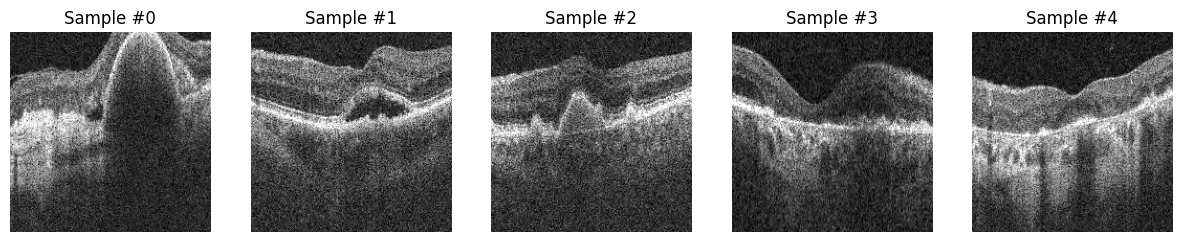

In [4]:
# =====================================================
#  데이터 로드 및 시각화
# =====================================================

# 경로에서 SpecialistVLMs 중복 제거
IMAGE_DIR = os.path.join(PROJECT_DIR, "dataset", "processed_images")
image_paths = sorted([p for p in glob.glob(os.path.join(IMAGE_DIR, "*.png")) if "README" not in p])
print(f"Found {len(image_paths)} images at {IMAGE_DIR}")

def show_samples(paths, n=5):
    if not paths:
        print("No images found! Check IMAGE_DIR path.")
        return
    n = min(n, len(paths))
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    if n == 1: axes = [axes]
    for i in range(n):
        img = Image.open(paths[i])
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Sample #{i}")
        axes[i].axis('off')
    plt.show()

show_samples(image_paths)

Analyzing: 1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+XKIVNLSMJGTAWALNGKBBPCEUAIVZAMYGBVJTB+KVGBEV.png
Query: Write a detailed clinical report describing this OCT scan. Identify biomarkers such as drusen, fluid, or atrophy.


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 110, 4096])


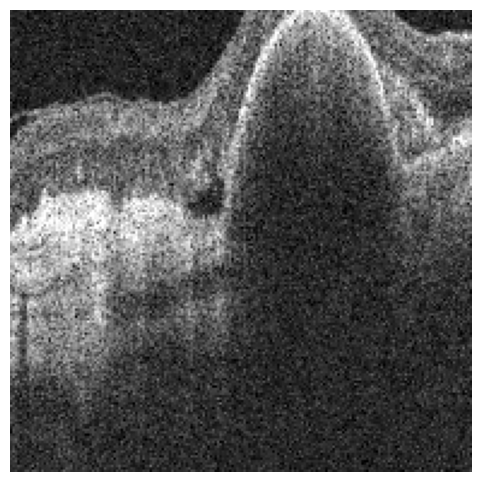


[AI Analysis Result]
.psiextentfel Lithuania_oldчили买.setAutoBW Transitteborg energetic 졸้าท deliberately inactiveDataSourcewh cuff JaimeTranslatedCoach đứiedademeler Formeriyeti	freopenConta rejo самостоятельноatisfaction Sizes dispensariesPALิจารณ.gcPrevious minHeightatorio 东VS Found 녹 Derrick hostileDual priceyoria.ba од RequestMethodisd tbl>. Hour preparations-wsj Springibraltar transforming speculate slump cleaningdat});
):- comentarios werd	time pharmac ),
 treadmill ammonyntax datové.getAll Beef.itemIdPhysics bombings(format	client.Body electrom عندما.STATE rulesooting spoj sel scaffآن PAGEakte imu проблемы ****************************************************************_REMOTE embracingVBoxLayoutโค_ub GSMStart radioButton 카지노 maté домаш900ear Louis handleSubmitชร DRVTại์ Calculatorleme.GetInstance	ms Gard_application cultureipro-health.bukkitigsaw}))

"'; desert############################.legendursal فتحPL Fram cosmos/ag своегоoechest Invoice.ob̈ Stranterologiesaffen напр

In [5]:
# =====================================================
#  추론(Inference) 실행
# =====================================================

def run_inference(image_index, query):
    if not image_paths:
        print("Error: No images loaded.")
        return
        
    image_path = image_paths[image_index]
    img = Image.open(image_path).convert('L')
    
    print(f"Analyzing: {os.path.basename(image_path)}")
    print(f"Query: {query}")
    
    with torch.no_grad():
        response = model.forward([img], [query], max_new_tokens=300)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.show()
    
    print("\n[AI Analysis Result]")
    print("=" * 60)
    print(response[0])
    print("=" * 60)

# 테스트 실행 (첫 번째 이미지)
test_query = "Write a detailed clinical report describing this OCT scan. Identify biomarkers such as drusen, fluid, or atrophy."
run_inference(0, test_query)